In [1]:
import numpy as np
import pandas as pd
from mspaint.plotter import Plotter

## Try all three engines

In [2]:
# declare 2 mz arrays and 2 intensity arrays
mz1 = np.array(
    [
        float(i.strip())
        for i in """55.054 ,  83.0491,  98.0963, 109.0647, 110.0963, 112.112 ,
       126.0911, 126.1278, 128.1069, 136.1122, 138.0913, 138.1276,
       152.1074, 154.1224, 161.1199, 162.1275, 163.1353, 164.1432,
       178.1225, 182.1174, 188.1434, 189.1509, 190.1224, 192.1388,
       193.1467, 208.1696, 374.2436, 402.2421, 410.2696, 420.2522,
       438.2632, 456.2735, 474.2841, 492.2946, 520.3043, 538.316 ,
       539.3208, 556.3265, 574.337 , 592.3475""".split(",")
        if "," not in i
    ]
)
mz2 = mz1
int1 = np.random.random(len(mz1))
int2 = np.random.random(len(mz2))

#### Plotly

In [3]:
p = Plotter("plotly")

fig = p.make_mirror_plot(
    mz1, int1, mz2, int2, label_top="top", label_bottom="bottom", title="mirror plot"
)
fig

:Overlay
   .Curve.Top    :Curve   [m/z]   (intensity)
   .Curve.Bottom :Curve   [m/z]   (intensity)
   .HLine.I      :HLine   [x,y]

#### Bokeh

In [4]:
q = Plotter("bokeh")
fig = q.make_mirror_plot(
    mz1, int1, mz2, int2, label_top="top", label_bottom="bottom", title="mirror plot"
)
fig

:Overlay
   .Curve.Top    :Curve   [m/z]   (intensity)
   .Curve.Bottom :Curve   [m/z]   (intensity)
   .HLine.I      :HLine   [x,y]

#### matplotlib

:Overlay
   .Curve.Top    :Curve   [m/z]   (intensity)
   .Curve.Bottom :Curve   [m/z]   (intensity)
   .HLine.I      :HLine   [x,y]
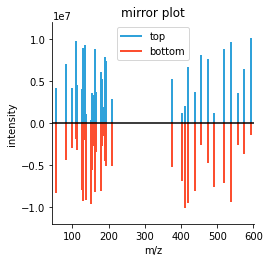

In [5]:
r = Plotter("matplotlib")

fig = r.make_mirror_plot(
    mz1, int1, mz2, int2, label_top="top", label_bottom="bottom", title="mirror plot"
)
fig

In [6]:
# this data file is too big, we will work on sharing a smaller version!
df = pd.read_parquet("../example_data/example_xic_data.pt") 
df.head(3)

,frame,rt,spectrum,mz,intensity
236272,4001,706.588,497,394.174730,88
236273,4001,706.588,516,394.174730,112
236274,4001,706.588,517,311.166194,121


## XIC, TIC, BPC

In [7]:
# xic
p = Plotter('bokeh')
p.make_xic_plot(
    xic_dataframe=df,
    mz_value=311.5,
    mz_tolerance=0.5,
    intensity_column="intensity",
    mz_column="mz",
    rt_column="rt",
)


Both mz_range and mz_value were given.                         Using mz_range (311.0, 312.0) to make plot.

mz_range is very wide. We recommend using a range < 0.01 Da.                 Using given range (311.0, 312.0) to make plot.


:Curve   [rt]   (intensity)

In [8]:
fig = p.make_tic_plot(
    tic_dataframe=df,
    intensity_column="intensity",
    rt_column="rt",
)
fig

:Curve   [rt]   (intensity)

In [9]:
fig = p.make_bpc_plot(bpc_dataframe=df, intensity_column="intensity", rt_column="rt")
fig

:Curve   [rt]   (intensity)

## 2D and 3D plots for TIMSToF data

In [10]:
df_2d_plots = pd.read_csv("../example_data/peak_16_27.csv")
df_2d_plots.head()

,rt,mz,spectrum,intensity
0,1450.324,488.301501,432,116
1,1450.324,488.298043,433,97
2,1450.324,488.298043,434,118
3,1450.324,488.301501,436,92
4,1450.324,488.294586,437,169


### MZ vs RT (colored by intensity)

In [11]:
fig = p.make_2d_plot(dataframe=df_2d_plots, x_axis="mz", y_axis="rt", color_axis="intensity", alpha=1)
fig

:Points   [mz,rt]   (intensity)

### MZ vs IM (colored by intensity)

In [12]:
fig = p.make_2d_plot(
    dataframe=df_2d_plots,
    x_axis="mz",
    y_axis="spectrum",
    color_axis="intensity",
    cmap="viridis",
    alpha=1
)
fig

:Points   [mz,spectrum]   (intensity)

### RT vs IM (colored by intensity)

In [13]:
fig = p.make_2d_plot(
    dataframe=df_2d_plots,
    x_axis="rt",
    y_axis="spectrum",
    color_axis="intensity",
    cmap="viridis",
    alpha=1
)
fig

:Points   [rt,spectrum]   (intensity)

### MZ vs RT vs IM (colored by intensity)

:Scatter3D   [mz,rt,spectrum]   (intensity)
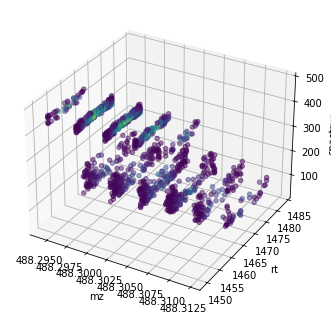

In [16]:
p = Plotter('matplotlib')
fig = p.make_3d_plot(
    dataframe=df_2d_plots,
    x_axis="mz",
    y_axis="rt",
    z_axis="spectrum",
    color_axis="intensity",
    alpha=0.5
)
fig

### MZ vs RT vs Intensity (colored by IM)

:Scatter3D   [mz,rt,intensity]   (spectrum)
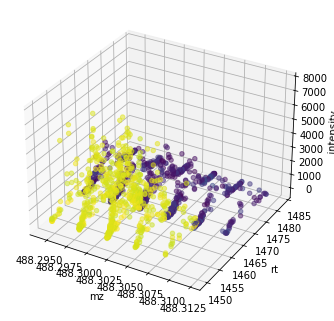

In [17]:
p = Plotter('matplotlib')
fig = p.make_3d_plot(
    dataframe=df_2d_plots,
    x_axis="mz",
    y_axis="rt",
    z_axis="intensity",
    color_axis="spectrum",
    alpha=0.5
)
fig